# Week 5 — Additional Models

This notebook trains and compares three regression models for predicting `ClosePrice`:

1. Linear Regression baseline
2. Decision Tree Regressor
3. Random Forest Regressor

The models are evaluated using a chronological split. April 2026 is used for validation and May 2026 is reserved as the final test month. `ListPrice`, `OriginalListPrice`, and other leakage-prone variables are excluded.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Import Libraries

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

pd.set_option("display.max_columns", 150)

RANDOM_SEED = 42
TARGET = "ClosePrice"

## 1. Load the Week 3 Cleaned Dataset

The cleaned dataset produced during Week 3 is used directly. No raw monthly files are reloaded in this notebook.

In [3]:
DATA_PATH_ENRICHED = (
    "/content/drive/MyDrive/IDX_Exchange_Su26/data/"
    "crmls_sfr_avm_cleaned_enriched_202501_202605.csv"
)

DATA_PATH_CLEANED = (
    "/content/drive/MyDrive/IDX_Exchange_Su26/data/"
    "crmls_sfr_quality_cleaned_202501_202605.csv"
)

if os.path.exists(DATA_PATH_ENRICHED):
    DATA_PATH = DATA_PATH_ENRICHED
elif os.path.exists(DATA_PATH_CLEANED):
    DATA_PATH = DATA_PATH_CLEANED
else:
    raise FileNotFoundError(
        "No cleaned Week 3 dataset was found."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print("Data path:", DATA_PATH)
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Data path: /content/drive/MyDrive/IDX_Exchange_Su26/data/crmls_sfr_avm_cleaned_enriched_202501_202605.csv
Shape: (181237, 93)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,source_month,close_month,PropertyAge,sale_month,month_sin,month_cos,DistrictName,LivingArea_missing,BathroomsTotalInteger_missing,LotSizeSquareFeet_missing,YearBuilt_missing,GarageSpaces_missing,Stories_missing
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",False,NaN,NaN,NaN,3288000.0,1097313841,josiechenn@yahoo.com,2025-01-01,3720000.0,Josie,Chen,37.305662,-122.012063,6139 Alcante Drive,Residential,2082.0,3288000.0,6,Intero Real Estate Services,Coldwell Banker Realty,NaN,Josie Chen,NaN,NaN,ML151425,Jeff,Bell,NaN,NaN,NaN,1097313841,699 - Not Defined,NaN,Santa Clara,Closed,Other,True,2.0,NaN,SingleFamilyResidence,0.2319,NaN,Mlslistings,1967.0,6139.0,ML81988000,3.0,San Jose,NaN,NaN,4.0,2025-01-01,NaN,NaN,2024-12-11,2024-12-05,NaN,NaN,CA,NaN,Other,True,NaN,Lynbrook,NaN,NaN,10100.0,NaN,False,2.0,Other,95129,NaN,10100.0,NaN,False,False,202501,2025-01,58.0,1,0.5,0.866025,Unknown,0,0,0,0,0,1
1,SierraNorthValley,SierraNorthValley,Wood,True,NaN,NaN,False,399000.0,1095538423,ernestsalinasrealtor@gmail.com,2025-01-01,400000.0,Ernest,Salinas,39.732504,-121.811735,1618 HARVEST GLEN DRIVE,Residential,1316.0,399000.0,18,"eXp Realty of California, Inc.",Glenn Fry Real Estate,NaN,Ernest Salinas,NaN,NaN,CH157000156,Glenn,Fry,NaN,NaN,NaN,1095538423,NaN,NaN,Butte,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1100,NaN,SierraNorthValley,2002.0,1618.0,SN24237888,2.0,Chico,NaN,NaN,3.0,2025-01-01,NaN,NaN,2024-12-31,2024-11-20,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,NaN,4791.0,3.0,False,2.0,Chico Unified,95928,0.0,4791.0,NaN,False,False,202501,2025-01,23.0,1,0.5,0.866025,Chico Unified,0,0,0,0,0,0
2,OrangeCounty,OrangeCounty,"Carpet,Vinyl",True,NaN,NaN,False,660595.0,1095479299,contact.socal@meritagehomes.com,2025-01-01,660595.0,Michelle,Shepherd,33.948930,-117.048727,35232 Guldahl Court,Residential,3152.0,660595.0,0,Meritage Homes of California,NONMEMBER MRML,NaN,Michelle Shepherd,NaN,NaN,NONMEMBER,General,NONMEMBER,NaN,Monthly,NaN,1095479299,263 - Banning/Beaumont/Cherry Valley,NaN,Riverside,Closed,NaN,True,3.0,Meritage Homes,SingleFamilyResidence,0.1452,Magnolia at The Fairways,Mrmls,2024.0,35232.0,OC24225616,4.0,Beaumont,NaN,NaN,5.0,2025-01-01,NaN,NaN,2024-11-19,2024-11-19,NaN,NaN,CA,NaN,NaN,False,2.0,Beaumont,Two,NaN,6323.0,1.0,True,3.0,Beaumont,92223,146.0,6323.0,NaN,False,False,202501,2025-01,1.0,1,0.5,0.866025,Beaumont Unified,0,0,0,0,0,0
3,CitrusValley,CitrusValley,NaN,False,NaN,NaN,True,1325888.0,1095146807,wjpartida@gmail.com,2025-01-01,1325000.0,William,Partida,33.948027,-117.986052,9835 Bogardus Avenue,Residential,2101.0,1325888.0,24,eHomes,Keller Williams College Park,NaN,William Partida,NaN,NaN,dwgonder,Derek,Gonzalez,NaN,NaN,NaN,1095146807,670 - Whittier,NaN,Los Angeles,Closed,Murphy Ranch,False,2.0,NaN,SingleFamilyResidence,0.2981,NaN,Downey,1955

## 2. Prepare the Target and Time Variable

`ClosePrice` is the target. `CloseDate` is converted into a monthly variable for chronological splitting.

In [4]:
if TARGET not in df.columns:
    raise KeyError(f"{TARGET} was not found in the dataset.")

if "CloseDate" not in df.columns:
    raise KeyError("CloseDate was not found in the dataset.")

df["CloseDate"] = pd.to_datetime(
    df["CloseDate"],
    errors="coerce"
)

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

df = df[
    df["CloseDate"].notna()
    & df[TARGET].notna()
    & (df[TARGET] > 0)
].copy()

df["close_month"] = (
    df["CloseDate"]
    .dt.to_period("M")
    .astype(str)
)

print("Available months:")
print(sorted(df["close_month"].unique()))

print("\nNumber of modeling rows:", len(df))

Available months:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']

Number of modeling rows: 181237


In [5]:
if "PropertyAge" not in df.columns:
    df["YearBuilt"] = pd.to_numeric(
        df["YearBuilt"],
        errors="coerce"
    )

    df["PropertyAge"] = (
        df["CloseDate"].dt.year
        - df["YearBuilt"]
    )

if "month_sin" not in df.columns:
    sale_month = df["CloseDate"].dt.month

    df["month_sin"] = np.sin(
        2 * np.pi * sale_month / 12
    )

    df["month_cos"] = np.cos(
        2 * np.pi * sale_month / 12
    )

df[
    [
        "CloseDate",
        "close_month",
        "PropertyAge",
        "month_sin",
        "month_cos"
    ]
].head()

,CloseDate,close_month,PropertyAge,month_sin,month_cos
0,2025-01-01,2025-01,58.0,0.5,0.866025
1,2025-01-01,2025-01,23.0,0.5,0.866025
2,2025-01-01,2025-01,1.0,0.5,0.866025
3,2025-01-01,2025-01,70.0,0.5,0.866025
4,2025-01-01,2025-01,30.0,0.5,0.866025


## 3. Select Model Features and Prevent Data Leakage

The same raw feature set is used for all models. `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, post-close variables, identifiers, and target-derived variables are excluded.

In [6]:
LEAKAGE_COLUMNS = {
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice_to_ListPrice_ratio",
    "DaysOnMarket",
    "CloseDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate",
    "MlsStatus",
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "UnparsedAddress"
}

numeric_candidates = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "PropertyAge",
    "GarageSpaces",
    "Stories",
    "Latitude",
    "Longitude",
    "month_sin",
    "month_cos",
    "LivingArea_missing",
    "BathroomsTotalInteger_missing",
    "LotSizeSquareFeet_missing",
    "YearBuilt_missing",
    "GarageSpaces_missing",
    "Stories_missing"
]

categorical_candidates = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "DistrictName",
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

numeric_features = [
    col
    for col in numeric_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

categorical_features = [
    col
    for col in categorical_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

feature_columns = (
    numeric_features
    + categorical_features
)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal raw features:")
print(len(feature_columns))

Numerical features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'PropertyAge', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude', 'month_sin', 'month_cos', 'LivingArea_missing', 'BathroomsTotalInteger_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'GarageSpaces_missing', 'Stories_missing']

Categorical features:
['City', 'PostalCode', 'CountyOrParish', 'DistrictName', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

Total raw features:
28


In [7]:
for col in numeric_features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).astype(float)

for col in categorical_features:
    # Convert categorical values to ordinary Python strings.
    # Missing values remain as np.nan for SimpleImputer.
    missing_mask = df[col].isna()

    df[col] = df[col].astype(object)

    df.loc[~missing_mask, col] = (
        df.loc[~missing_mask, col]
        .astype(str)
    )

    df.loc[missing_mask, col] = np.nan

print("Feature types prepared for scikit-learn.")

remaining_missing = (
    df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values handled later by model pipelines:")
print(remaining_missing[remaining_missing > 0])

Feature types prepared for scikit-learn.

Missing values handled later by model pipelines:
WaterfrontYN             181141
BasementYN               176865
AttachedGarageYN          21729
Stories                   19542
ViewYN                    16238
PoolPrivateYN             14361
NewConstructionYN         13700
GarageSpaces               7055
LotSizeSquareFeet          3160
FireplaceYN                 133
PropertyAge                 103
LivingArea                   97
City                         83
BathroomsTotalInteger        20
Latitude                     17
Longitude                    17
PostalCode                    2
dtype: int64


## 4. Evaluation Metrics

R² is the required Week 5 metric. MAE, RMSE, MAPE, and MdAPE are also reported to provide additional information about dollar and percentage errors.

In [8]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    percentage_errors = (
        np.abs(y_true - y_pred)
        / np.abs(y_true)
    ) * 100

    return {
        "R2": r2_score(y_true, y_pred),

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "MAPE": (
            mean_absolute_percentage_error(
                y_true,
                y_pred
            ) * 100
        ),

        "MdAPE": np.median(
            percentage_errors
        )
    }

## 5. Build Model-Specific Preprocessing Pipelines

Linear Regression uses standardized numerical features and one-hot encoded categorical variables.

Decision Tree and Random Forest do not require scaling. Categorical variables are ordinal encoded so that the tree models receive numerical inputs without creating a very large one-hot feature matrix.

In [9]:
linear_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

linear_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                min_frequency=20
            )
        )
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            linear_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            linear_categorical_pipeline,
            categorical_features
        )
    ]
)

In [10]:
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            tree_categorical_pipeline,
            categorical_features
        )
    ]
)

## 6. Select the Training Window Using April 2026

The candidate training-window lengths are evaluated using April 2026 as the validation month. May 2026 is not used during this selection process.

In [11]:
available_months = sorted(
    df["close_month"]
    .dropna()
    .unique()
)

test_month = available_months[-1]
validation_month = available_months[-2]

test_period = pd.Period(
    test_month,
    freq="M"
)

validation_period = pd.Period(
    validation_month,
    freq="M"
)

training_end_period = (
    validation_period - 1
)

df_month_period = pd.PeriodIndex(
    df["close_month"],
    freq="M"
)

print("Validation month:", validation_month)
print("Final test month:", test_month)

Validation month: 2026-04
Final test month: 2026-05


In [13]:
# Compare Training Windows
TRAINING_WINDOW_CANDIDATES = [
    3,
    6,
    9,
    12,
    15
]

window_results = []

for window in TRAINING_WINDOW_CANDIDATES:

    training_start_period = (
        training_end_period
        - (window - 1)
    )

    train_mask = (
        (df_month_period >= training_start_period)
        & (df_month_period <= training_end_period)
    )

    validation_mask = (
        df_month_period == validation_period
    )

    train_data = df.loc[
        train_mask
    ].copy()

    validation_data = df.loc[
        validation_mask
    ].copy()

    if train_data.empty:
        continue

    # Learn ClosePrice outlier thresholds
    # from training data only.
    lower_price = train_data[
        TARGET
    ].quantile(0.005)

    upper_price = train_data[
        TARGET
    ].quantile(0.995)

    train_data = train_data[
        train_data[TARGET].between(
            lower_price,
            upper_price
        )
    ].copy()

    validation_data = validation_data[
        validation_data[TARGET].between(
            lower_price,
            upper_price
        )
    ].copy()

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                linear_preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    )

    model.fit(
        train_data[feature_columns],
        train_data[TARGET]
    )

    validation_predictions = model.predict(
        validation_data[feature_columns]
    )

    metrics = calculate_metrics(
        validation_data[TARGET],
        validation_predictions
    )

    window_results.append({
        "Training_Window_Months": window,
        "Training_Start": str(
            training_start_period
        ),
        "Training_End": str(
            training_end_period
        ),
        "Validation_Month": validation_month,
        "Training_Rows": len(train_data),
        "Validation_Rows": len(
            validation_data
        ),
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MAPE": metrics["MAPE"],
        "Validation_MdAPE": metrics["MdAPE"]
    })

window_results_df = pd.DataFrame(
    window_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

window_results_df

,Training_Window_Months,Training_Start,Training_End,Validation_Month,Training_Rows,Validation_Rows,Validation_R2,Validation_MAE,Validation_MAPE,Validation_MdAPE
0,15,2025-01,2026-03,2026-04,155626,11890,0.822027,243957.755442,22.462295,15.574437
1,12,2025-04,2026-03,2026-04,128362,11897,0.821947,244674.690653,22.603297,15.732439
2,9,2025-07,2026-03,2026-04,93410,11902,0.817200,247771.922384,22.766980,15.733547
3,6,2025-10,2026-03,2026-04,58770,11907,0.811778,253454.982568,23.268982,15.984734
4,3,2026-01,2026-03,2026-04,26914,11914,0.774652,285072.564834,27.080388,18.493804


In [14]:
# Select Best X
BEST_X = int(
    window_results_df.loc[
        0,
        "Training_Window_Months"
    ]
)

print(
    "Selected training window:",
    BEST_X,
    "months"
)

print(
    "Best validation R²:",
    f"{window_results_df.loc[0, 'Validation_R2']:.4f}"
)

Selected training window: 15 months
Best validation R²: 0.8220


## 7. Create the Tuning Training Set and Validation Set

The selected training window is now used to tune the Decision Tree and Random Forest.

In [15]:
tuning_train_start = (
    training_end_period
    - (BEST_X - 1)
)

tuning_train_mask = (
    (df_month_period >= tuning_train_start)
    & (df_month_period <= training_end_period)
)

validation_mask = (
    df_month_period == validation_period
)

tuning_train_df = df.loc[
    tuning_train_mask
].copy()

validation_df = df.loc[
    validation_mask
].copy()

tuning_lower_price = (
    tuning_train_df[TARGET]
    .quantile(0.005)
)

tuning_upper_price = (
    tuning_train_df[TARGET]
    .quantile(0.995)
)

tuning_train_df = tuning_train_df[
    tuning_train_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

validation_df = validation_df[
    validation_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

X_tuning_train = tuning_train_df[
    feature_columns
]

y_tuning_train = tuning_train_df[
    TARGET
]

X_validation = validation_df[
    feature_columns
]

y_validation = validation_df[
    TARGET
]

print(
    "Tuning training period:",
    tuning_train_df["close_month"].min(),
    "to",
    tuning_train_df["close_month"].max()
)

print("Validation month:", validation_month)
print("Training rows:", len(tuning_train_df))
print("Validation rows:", len(validation_df))

Tuning training period: 2025-01 to 2026-03
Validation month: 2026-04
Training rows: 155626
Validation rows: 11890


## 8. Tune the Decision Tree

A small validation search is used to control tree depth and minimum leaf size. These parameters help reduce overfitting.

In [16]:
decision_tree_candidates = [
    {
        "max_depth": 6,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 8,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 10,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 8,
        "min_samples_leaf": 30
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 30
    }
]

decision_tree_results = []

for params in decision_tree_candidates:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_SEED,
                    max_depth=params[
                        "max_depth"
                    ],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ]
                )
            )
        ]
    )

    start_time = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    validation_predictions = model.predict(
        X_validation
    )

    elapsed_time = (
        time.time() - start_time
    )

    metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    decision_tree_results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params[
            "min_samples_leaf"
        ],
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MdAPE": metrics[
            "MdAPE"
        ],
        "Fit_Seconds": elapsed_time
    })

decision_tree_results_df = pd.DataFrame(
    decision_tree_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

decision_tree_results_df

,max_depth,min_samples_leaf,Validation_R2,Validation_MAE,Validation_MdAPE,Fit_Seconds
0,12,10,0.793007,242801.570670,12.895656,3.647299
1,12,30,0.785777,247884.047581,12.961440,8.371111
2,10,10,0.758376,274219.630990,15.286222,2.984431
3,8,10,0.703806,315583.444509,18.803136,4.231527
4,8,30,0.700614,317113.514355,18.873335,2.667349
5,6,10,0.609486,377497.178941,22.600984,2.661237


In [17]:
# Best Decision Tree Parameters
BEST_DT_PARAMS = {
    "max_depth": int(
        decision_tree_results_df.loc[
            0,
            "max_depth"
        ]
    ),

    "min_samples_leaf": int(
        decision_tree_results_df.loc[
            0,
            "min_samples_leaf"
        ]
    )
}

print(
    "Best Decision Tree parameters:",
    BEST_DT_PARAMS
)

print(
    "Best Decision Tree validation R²:",
    f"{decision_tree_results_df.loc[0, 'Validation_R2']:.4f}"
)

Best Decision Tree parameters: {'max_depth': 12, 'min_samples_leaf': 10}
Best Decision Tree validation R²: 0.7930


## 9. Tune the Random Forest

Random Forest averages many Decision Trees to reduce variance. A small validation search is used to compare depth, leaf size, and feature-sampling choices.

In [19]:
random_forest_candidates = [
    {
        "max_depth": 12,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "max_depth": 18,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "max_depth": 18,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 0.7
    },
    {
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": 0.7
    }
]

random_forest_results = []

for params in random_forest_candidates:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=100,
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                    max_depth=params[
                        "max_depth"
                    ],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ],
                    max_features=params[
                        "max_features"
                    ]
                )
            )
        ]
    )

    start_time = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    validation_predictions = model.predict(
        X_validation
    )

    elapsed_time = (
        time.time() - start_time
    )

    metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    random_forest_results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params[
            "min_samples_leaf"
        ],
        "max_features": params[
            "max_features"
        ],
        "n_estimators": 100,
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MdAPE": metrics[
            "MdAPE"
        ],
        "Fit_Seconds": elapsed_time
    })

random_forest_results_df = pd.DataFrame(
    random_forest_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

random_forest_results_df

,max_depth,min_samples_leaf,max_features,n_estimators,Validation_R2,Validation_MAE,Validation_MdAPE,Fit_Seconds
0,NaN,1,0.7,100,0.878182,168938.648526,7.910812,184.595136
1,NaN,5,0.7,100,0.873033,171841.272372,7.927996,135.721666
2,18.0,1,sqrt,100,0.858255,192192.237640,9.729560,58.698561
3,18.0,5,sqrt,100,0.846205,200473.981590,10.152870,37.200126
4,12.0,1,sqrt,100,0.795867,251367.150264,15.112000,47.751565
5,12.0,5,sqrt,100,0.791828,252987.615398,15.371839,36.188315


In [20]:
# Best Random Forest Parameters
best_depth_value = (
    random_forest_results_df.loc[
        0,
        "max_depth"
    ]
)

if pd.isna(best_depth_value):
    best_depth_value = None
else:
    best_depth_value = int(
        best_depth_value
    )

best_max_features = (
    random_forest_results_df.loc[
        0,
        "max_features"
    ]
)

try:
    best_max_features = float(
        best_max_features
    )
except (TypeError, ValueError):
    best_max_features = str(
        best_max_features
    )

BEST_RF_PARAMS = {
    "n_estimators": 100,

    "max_depth": best_depth_value,

    "min_samples_leaf": int(
        random_forest_results_df.loc[
            0,
            "min_samples_leaf"
        ]
    ),

    "max_features": best_max_features
}

print(
    "Best Random Forest parameters:",
    BEST_RF_PARAMS
)

print(
    "Best Random Forest validation R²:",
    f"{random_forest_results_df.loc[0, 'Validation_R2']:.4f}"
)

Best Random Forest parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.7}
Best Random Forest validation R²: 0.8782


## 10. Final Train/Test Split

After selecting the training-window length and tree parameters using April 2026, the final models are trained using the selected number of months ending in April 2026.

May 2026 is then used once for final testing.

In [21]:
final_train_end = (
    test_period - 1
)

final_train_start = (
    final_train_end
    - (BEST_X - 1)
)

final_train_mask = (
    (df_month_period >= final_train_start)
    & (df_month_period <= final_train_end)
)

test_mask = (
    df_month_period == test_period
)

final_train_df = df.loc[
    final_train_mask
].copy()

test_df = df.loc[
    test_mask
].copy()

# Learn outlier thresholds
# from final training data only.
final_lower_price = (
    final_train_df[TARGET]
    .quantile(0.005)
)

final_upper_price = (
    final_train_df[TARGET]
    .quantile(0.995)
)

final_train_df = final_train_df[
    final_train_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()

test_df = test_df[
    test_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()

X_train = final_train_df[
    feature_columns
]

y_train = final_train_df[
    TARGET
]

X_test = test_df[
    feature_columns
]

y_test = test_df[
    TARGET
]

print(
    "Final training period:",
    final_train_df["close_month"].min(),
    "to",
    final_train_df["close_month"].max()
)

print("Test month:", test_month)
print("Training rows:", len(final_train_df))
print("Test rows:", len(test_df))

print(
    "Frozen target bounds:",
    f"${final_lower_price:,.0f}",
    "to",
    f"${final_upper_price:,.0f}"
)

Final training period: 2025-02 to 2026-04
Test month: 2026-05
Training rows: 159478
Test rows: 11906
Frozen target bounds: $187,000 to $8,817,250


## 11. Train the Three Final Models

In [22]:
# Define Models
models = {
    "Linear Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                linear_preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_SEED,
                    max_depth=BEST_DT_PARAMS[
                        "max_depth"
                    ],
                    min_samples_leaf=BEST_DT_PARAMS[
                        "min_samples_leaf"
                    ]
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=BEST_RF_PARAMS[
                        "n_estimators"
                    ],
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                    max_depth=BEST_RF_PARAMS[
                        "max_depth"
                    ],
                    min_samples_leaf=BEST_RF_PARAMS[
                        "min_samples_leaf"
                    ],
                    max_features=BEST_RF_PARAMS[
                        "max_features"
                    ]
                )
            )
        ]
    )
}

In [23]:
# Train and Evaluate
model_results = []

test_predictions = {}

fitted_models = {}

for model_name, model in models.items():

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    fit_seconds = (
        time.time() - start_time
    )

    train_predictions = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_metrics = calculate_metrics(
        y_train,
        train_predictions
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    model_results.append({
        "Model": model_name,
        "Training_Window_Months": BEST_X,
        "Training_Start": str(
            final_train_start
        ),
        "Training_End": str(
            final_train_end
        ),
        "Test_Month": test_month,
        "Train_R2": train_metrics["R2"],
        "Test_R2": test_metrics["R2"],
        "Test_MAE": test_metrics["MAE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Test_MAPE": test_metrics["MAPE"],
        "Test_MdAPE": test_metrics["MdAPE"],
        "Fit_Seconds": fit_seconds
    })

    test_predictions[
        model_name
    ] = test_pred

    fitted_models[
        model_name
    ] = model

results_df = pd.DataFrame(
    model_results
).sort_values(
    "Test_R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Training_Window_Months,Training_Start,Training_End,Test_Month,Train_R2,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_MdAPE,Fit_Seconds
0,Random Forest,15,2025-02,2026-04,2026-05,0.984267,0.877634,171194.111141,348585.473505,12.783479,7.829652,192.906661
1,Linear Regression,15,2025-02,2026-04,2026-05,0.827246,0.828764,240835.835093,412359.753390,21.931216,15.240545,37.109296
2,Decision Tree,15,2025-02,2026-04,2026-05,0.854574,0.802075,241740.651669,443331.762609,18.614276,12.759565,4.225376


In [24]:
# Improvement Over Baseline
baseline_r2 = float(
    results_df.loc[
        results_df["Model"]
        == "Linear Regression",
        "Test_R2"
    ].iloc[0]
)

results_df[
    "R2_Improvement_Over_Baseline"
] = (
    results_df["Test_R2"]
    - baseline_r2
)

results_df

,Model,Training_Window_Months,Training_Start,Training_End,Test_Month,Train_R2,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_MdAPE,Fit_Seconds,R2_Improvement_Over_Baseline
0,Random Forest,15,2025-02,2026-04,2026-05,0.984267,0.877634,171194.111141,348585.473505,12.783479,7.829652,192.906661,0.048870
1,Linear Regression,15,2025-02,2026-04,2026-05,0.827246,0.828764,240835.835093,412359.753390,21.931216,15.240545,37.109296,0.000000
2,Decision Tree,15,2025-02,2026-04,2026-05,0.854574,0.802075,241740.651669,443331.762609,18.614276,12.759565,4.225376,-0.026689


## 12. Compare Test R²

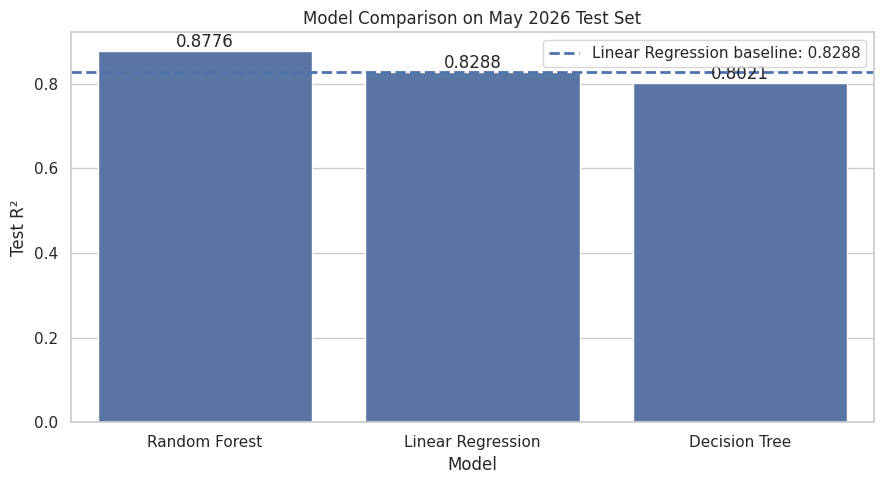

In [25]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Test_R2"
)

plt.axhline(
    baseline_r2,
    linestyle="--",
    linewidth=2,
    label=(
        "Linear Regression baseline: "
        f"{baseline_r2:.4f}"
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f"
    )

plt.title(
    "Model Comparison on May 2026 Test Set"
)

plt.xlabel("Model")
plt.ylabel("Test R²")

plt.legend()

plt.tight_layout()
plt.show()

## 13. Actual vs. Predicted ClosePrice

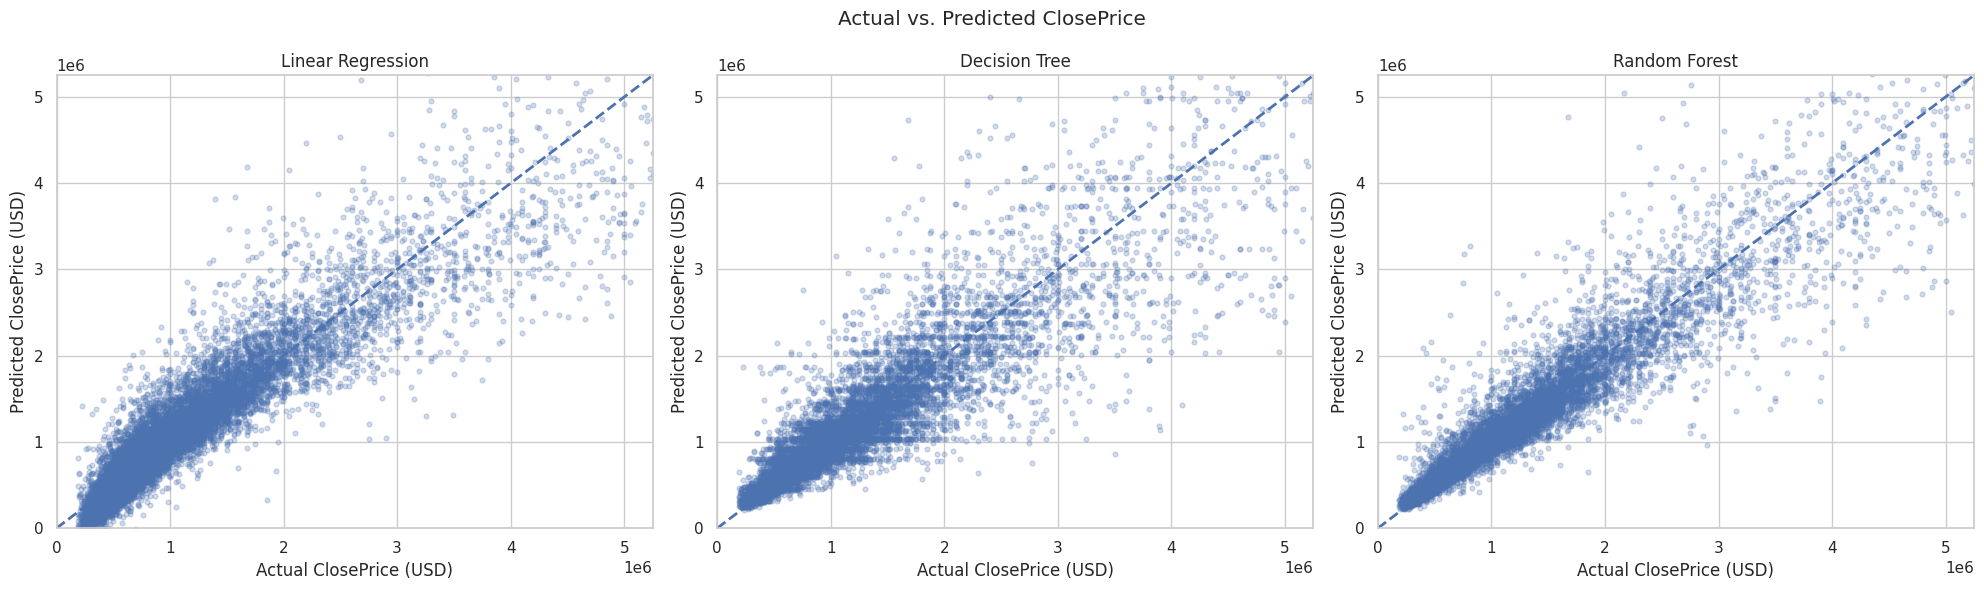

In [26]:
plot_limit = max(
    y_test.quantile(0.99),

    max(
        np.quantile(
            prediction,
            0.99
        )
        for prediction
        in test_predictions.values()
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

for ax, (
    model_name,
    predictions
) in zip(
    axes,
    test_predictions.items()
):

    ax.scatter(
        y_test,
        predictions,
        alpha=0.25,
        s=12
    )

    ax.plot(
        [0, plot_limit],
        [0, plot_limit],
        linestyle="--",
        linewidth=2
    )

    ax.set_xlim(
        0,
        plot_limit
    )

    ax.set_ylim(
        0,
        plot_limit
    )

    ax.set_title(model_name)

    ax.set_xlabel(
        "Actual ClosePrice (USD)"
    )

    ax.set_ylabel(
        "Predicted ClosePrice (USD)"
    )

plt.suptitle(
    "Actual vs. Predicted ClosePrice"
)

plt.tight_layout()
plt.show()

## 14. Random Forest Feature Importance

In [27]:
rf_pipeline = fitted_models[
    "Random Forest"
]

rf_preprocessor = rf_pipeline.named_steps[
    "preprocessor"
]

rf_model = rf_pipeline.named_steps[
    "model"
]

rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

rf_importance_df.head(20)

,Feature,Importance
0,numeric__LivingArea,0.224367
1,numeric__BathroomsTotalInteger,0.193365
2,numeric__Longitude,0.152483
3,numeric__Latitude,0.141019
4,categorical__PostalCode,0.087752
5,categorical__CountyOrParish,0.036025
6,numeric__PropertyAge,0.035114
7,numeric__LotSizeSquareFeet,0.030032
8,numeric__Stories_missing,0.019543
9,categorical__DistrictName,0.019498


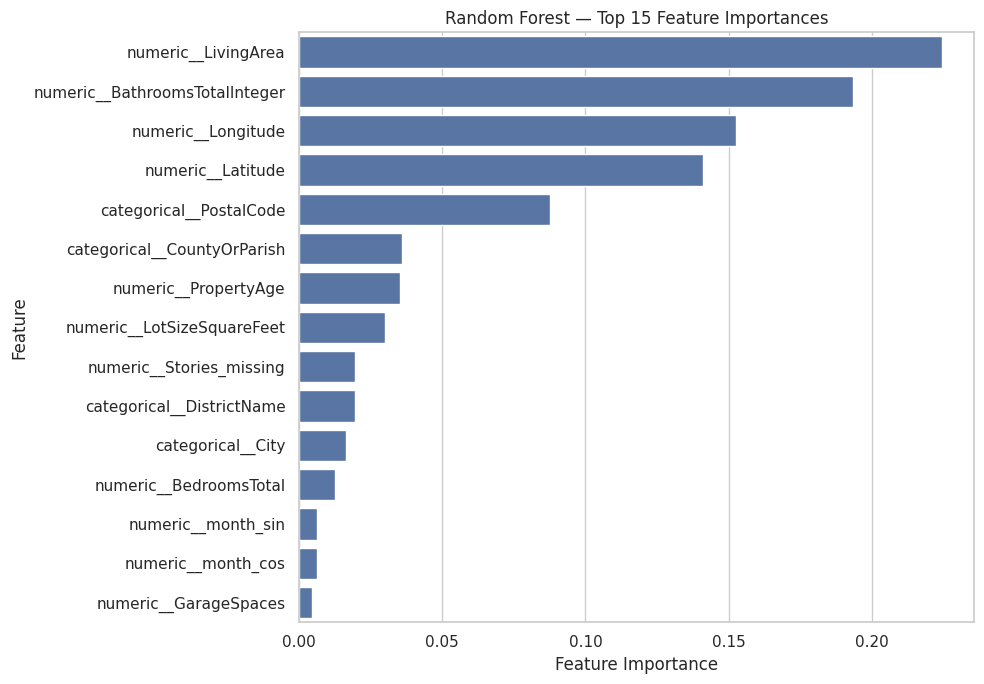

In [28]:
# Plot Feature Importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest — Top 15 Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 15. Model Behavior: Strengths and Weaknesses

### Linear Regression

**Strengths**

- Fast to train and easy to reproduce.
- Provides a clear benchmark for more advanced models.
- Works well when feature effects are approximately linear and additive.
- Coefficients can be interpreted after preprocessing.

**Weaknesses**

- Cannot naturally model nonlinear relationships.
- Does not automatically capture complex interactions.
- May underfit geographic and luxury-market effects.
- Can be sensitive to multicollinearity and extreme observations.

### Decision Tree

**Strengths**

- Captures nonlinear relationships.
- Automatically learns feature interactions.
- Does not require numerical feature scaling.
- Produces intuitive decision rules.

**Weaknesses**

- A single tree can overfit the training data.
- Small data changes may produce a substantially different tree.
- Deep trees can have high variance.
- Predictions are piecewise constant.

### Random Forest

**Strengths**

- Captures nonlinear relationships and interactions.
- Reduces the variance of a single tree by averaging many trees.
- Usually generalizes better than one Decision Tree.
- Handles mixed property and location features well.
- Provides feature-importance estimates.

**Weaknesses**

- Requires more training time and memory.
- Is less interpretable than Linear Regression or one shallow tree.
- Standard Random Forests cannot extrapolate beyond the target values observed during training.
- Feature importance may favor variables that offer many possible split points.

## 16. Save Results

In [29]:
OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "IDX_Exchange_Su26/data/"
    "week5_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

results_path = os.path.join(
    OUTPUT_DIR,
    "week5_model_comparison_results.csv"
)

window_path = os.path.join(
    OUTPUT_DIR,
    "week5_training_window_results.csv"
)

dt_path = os.path.join(
    OUTPUT_DIR,
    "week5_decision_tree_validation.csv"
)

rf_path = os.path.join(
    OUTPUT_DIR,
    "week5_random_forest_validation.csv"
)

importance_path = os.path.join(
    OUTPUT_DIR,
    "week5_random_forest_feature_importance.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

window_results_df.to_csv(
    window_path,
    index=False
)

decision_tree_results_df.to_csv(
    dt_path,
    index=False
)

random_forest_results_df.to_csv(
    rf_path,
    index=False
)

rf_importance_df.to_csv(
    importance_path,
    index=False
)

print("Saved model comparison:", results_path)
print("Saved window results:", window_path)
print("Saved Decision Tree tuning:", dt_path)
print("Saved Random Forest tuning:", rf_path)
print("Saved feature importance:", importance_path)

Saved model comparison: /content/drive/MyDrive/IDX_Exchange_Su26/data/week5_outputs/week5_model_comparison_results.csv
Saved window results: /content/drive/MyDrive/IDX_Exchange_Su26/data/week5_outputs/week5_training_window_results.csv
Saved Decision Tree tuning: /content/drive/MyDrive/IDX_Exchange_Su26/data/week5_outputs/week5_decision_tree_validation.csv
Saved Random Forest tuning: /content/drive/MyDrive/IDX_Exchange_Su26/data/week5_outputs/week5_random_forest_validation.csv
Saved feature importance: /content/drive/MyDrive/IDX_Exchange_Su26/data/week5_outputs/week5_random_forest_feature_importance.csv


In [30]:
# Final Summary
best_model = results_df.iloc[0]

print("WEEK 5 MODEL COMPARISON SUMMARY")
print("=" * 60)

print(
    "Selected training window:",
    BEST_X,
    "months"
)

print("Validation month:", validation_month)
print("Test month:", test_month)

print("\nModel results:\n")

print(
    results_df[
        [
            "Model",
            "Train_R2",
            "Test_R2",
            "R2_Improvement_Over_Baseline",
            "Test_MAE",
            "Test_MAPE",
            "Test_MdAPE",
            "Fit_Seconds"
        ]
    ].to_string(index=False)
)

print("\nBest model:", best_model["Model"])

print(
    "Best test R²:",
    f"{best_model['Test_R2']:.4f}"
)

WEEK 5 MODEL COMPARISON SUMMARY
Selected training window: 15 months
Validation month: 2026-04
Test month: 2026-05

Model results:

            Model  Train_R2  Test_R2  R2_Improvement_Over_Baseline      Test_MAE  Test_MAPE  Test_MdAPE  Fit_Seconds
    Random Forest  0.984267 0.877634                      0.048870 171194.111141  12.783479    7.829652   192.906661
Linear Regression  0.827246 0.828764                      0.000000 240835.835093  21.931216   15.240545    37.109296
    Decision Tree  0.854574 0.802075                     -0.026689 241740.651669  18.614276   12.759565     4.225376

Best model: Random Forest
Best test R²: 0.8776


## Conclusion

The Decision Tree and Random Forest regressors were compared with the Linear Regression baseline using the same feature set and chronological evaluation design.

The training-window length was selected using April 2026 as the validation month, while May 2026 was reserved for final testing. The selected training window was **15 months**.

The final test results were:

- Linear Regression R²: **0.8288**
- Decision Tree R²: **0.8021**
- Random Forest R²: **0.8776**

The **Random Forest** achieved the highest test R², improving over the Linear Regression baseline by **0.0489**, or approximately **4.9 percentage points**.

The Decision Tree captured nonlinear relationships but showed greater sensitivity to overfitting. Its training R² was **0.8546**, while its test R² decreased to **0.8021**, and it performed worse than the Linear Regression baseline on the final test set.

The Random Forest achieved a substantially higher training R² of **0.9843** and a test R² of **0.8776**. Although the difference between its training and test performance indicates some overfitting, the model still generalized better than both the Linear Regression and single Decision Tree models. By averaging predictions across many trees, the Random Forest reduced the instability and variance associated with a single Decision Tree.

The Random Forest also produced the lowest test error, with an MAE of approximately ** $171,194 **.

A MAPE of ** 12.78 percent **, and a median absolute percentage error of **7.83% **.

In comparison, the Linear Regression had an MAE of approximately ** $240,836 **.

While the Decision Tree had an MAE of approximately ** $241,741 **.

Overall, the Random Forest was the strongest model for this Week 5 comparison. It provided the best predictive performance and captured nonlinear relationships and feature interactions more effectively than the Linear Regression baseline. Its main disadvantages were its longer training time and lower interpretability compared with the other two models.